In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 42

np.random.seed(SEED)         # Celui de  NumPy 
torch.manual_seed(SEED)      # Celui de Pytorch


# --- 1. Chargement et préparation des données ---
# Charger les trajectoires des 2 classes
data_class1 = np.load("class1_trajectories.npy")  
data_class2 = np.load("class2_trajectories.npy")  
# On ajoute la 3eme classe manquante
data_class3 = np.load("class3_trajectories.npy")
data = np.concatenate((data_class1, data_class2, data_class3))    
    
# Construction des labels ---
labels = np.concatenate((np.zeros(data_class1.shape[0]), np.ones(data_class2.shape[0]), 2*np.ones(data_class3.shape[0])))

# --- 2. Split train/val/test ---
n_samples = data.shape[0]
indices = np.arange(n_samples)
np.random.seed(30)
np.random.shuffle(indices) 

train_size = int(0.8 * n_samples)
val_size = int(0.1 * n_samples)
test_size = n_samples - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

train_data = data[train_indices]
train_labels = labels[train_indices]
val_data = data[val_indices]
val_labels = labels[val_indices]
test_data = data[test_indices]
test_labels = labels[test_indices]

# Normalisation éventuelle
#nous devons normalizer les données pour que les trajectoires 
# soient comparables et bien sur stabiliser et eviter unstable training 
#pour cela nous utilisons z score normalization : https://www.geeksforgeeks.org/data-analysis/z-score-normalization-definition-and-examples/
# cette normalization centre les données et les reduit a une variance de 1
# pour chaque trajectoire, nous calculons la moyenne et l'ecart type
# puis on normalise les données en subtractant la moyenne et en divisant par l'écart type
#on peut aussi essayer min-max normalization : https://medium.com/@abhi1achiever/min-max-normalization-db1f515b08b4

#on reshape les données pour que chaque trajectoire soit une seule ligne
train_flat = train_data.reshape(-1, train_data.shape[-1])
#on calcule la moyenne et l'écart type de chaque trajectoire
mean = train_flat.mean(axis=0)
std = train_flat.std(axis=0)
std = np.where(std == 0, 1e-6, std) #pour eviter la division par 0 (RuntimeWarning: invalid value encountered in divide)

#on essaie d'abord de normaliser les données
train_normalized = (train_data - mean)/std
val_normalized = (val_data - mean)/std
test_normalized = (test_data - mean)/std



# --- 3. Dataset PyTorch pour la classification ---
class TrajectoryClassificationDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):# pour récupérer un échantillon (x, y) dans le dataset
        x = self.data[idx]
        y = self.labels[idx] #on prend le label de l'echantillon
        return torch.FloatTensor(x), torch.LongTensor([y])

# On crée les datasets
train_dataset = TrajectoryClassificationDataset(train_data, train_labels)
val_dataset = TrajectoryClassificationDataset(val_data, val_labels)
test_dataset = TrajectoryClassificationDataset(test_data, test_labels)

# On créé les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- 4. Modèle pour la classification ---
class MonModele(nn.Module):
    def __init__(self, input_size=20, hidden_size = 64, num_layers=2, output_size=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.lstm(x) #nous donne la sortie de la derniere couche LSTM
        x = self.fc(x[:, -1, :]) #nous donne la sortie de la derniere couche FC
        return x

# --- 5. Instanciation et entraînement ---
model = MonModele(input_size=20, hidden_size = 64, num_layers=2, output_size=3)
criterion = nn.CrossEntropyLoss() #nous utilisons la fonction de perte CrossEntropyLoss
optimizer = optim.Adam(model.parameters(), lr=0.001) #nous utilisons l'optimiseur Adam

n_epochs = 20 #nous utilisons 10 epochs pour l'entrainement
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0
    correct = 0
    total = 0
    for x_batch, y_batch in train_loader:
        y_batch = y_batch.squeeze()  #nous transformons les labels en 1D (pour eviter RuntimeError: 0D or 1D target tensor expected)
        optimizer.zero_grad()
        y_pred = model(x_batch) #nous donne la sortie de la derniere couche FC
        loss = criterion(y_pred, y_batch) #nous calculons la fonction de perte : probleme : shape des labels doit etre 1D mais là elle est de 2D
        loss.backward() #nous calculons le gradient de la fonction de perte
        optimizer.step() #nous mettons a jour les parametres du modele
        epoch_train_loss += loss.item() #nous sommons les pertes moyennes pour chaque batch
        _, predicted = torch.max(y_pred.data, 1) #nous donne la prediction du modele
        total += y_batch.size(0) #nous ajoutons le nombre d'echantillons a la liste des total
        correct += (predicted == y_batch.squeeze()).sum().item() #nous comptons le nombre de prédictions correctes et les additionnons dans le compteur "correct"
    train_losses.append(epoch_train_loss / len(train_loader)) #nous calculons la moyenne des loss par époque d'entrainement et l'ajoutons à la liste des train_losses
    train_accs.append(100 * correct / total) #nous calculons l'accuracy = taux de bonnes prédictions totales de l'époque et l'ajoutons à la liste correspondante

    # Validation
    model.eval()
    epoch_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_batch = y_batch.squeeze() #nous transformons les labels en 1D (pour eviter RuntimeError: 0D or 1D target tensor expected)
            y_pred = model(x_batch) #nous donne la sortie de la derniere couche FC
            loss = criterion(y_pred, y_batch) #nous calculons la fonction de perte
            epoch_val_loss += loss.item() #nous sommons les pertes moyennes pour chaque batch
            _, predicted = torch.max(y_pred.data, 1) #nous donne la prediction du modele
            total += y_batch.size(0) #nous ajoutons le nombre d'echantillons a la liste des total
            correct += (predicted == y_batch.squeeze()).sum().item() #nous comptons le nombre de prédictions correctes et les additionnons dans le compteur "correct"
    val_losses.append(epoch_val_loss / len(val_loader)) #nous calculons la moyenne des loss par époque de validation et l'ajoutons à la liste des train_losses
    val_accs.append(100 * correct / total) #nous calculons l'accuracy = taux de bonnes prédictions totales de l'époque et l'ajoutons à la liste correspondante

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}%, Val Acc: {val_accs[-1]:.2f}%")


# A COMPLETER

#print(epoch_val_loss)

/tmp/ipykernel_151275/3339120426.py:81: DeprecationWarning: an integer is required (got type numpy.float64).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  return torch.FloatTensor(x), torch.LongTensor([y])


Epoch 1/20, Train Loss: 1.0996, Val Loss: 1.1021, Train Acc: 34.36%, Val Acc: 25.00%
Epoch 2/20, Train Loss: 1.0996, Val Loss: 1.1048, Train Acc: 34.53%, Val Acc: 25.00%
Epoch 3/20, Train Loss: 1.0966, Val Loss: 1.0951, Train Acc: 40.23%, Val Acc: 36.84%
Epoch 4/20, Train Loss: 1.0668, Val Loss: 0.9669, Train Acc: 39.58%, Val Acc: 36.84%
Epoch 5/20, Train Loss: 0.8175, Val Loss: 0.6073, Train Acc: 60.26%, Val Acc: 71.05%
Epoch 6/20, Train Loss: 0.9919, Val Loss: 0.6114, Train Acc: 60.26%, Val Acc: 73.68%
Epoch 7/20, Train Loss: 0.9155, Val Loss: 0.7422, Train Acc: 51.63%, Val Acc: 55.26%
Epoch 8/20, Train Loss: 0.8539, Val Loss: 0.7259, Train Acc: 56.03%, Val Acc: 71.05%
Epoch 9/20, Train Loss: 0.8676, Val Loss: 0.7331, Train Acc: 56.19%, Val Acc: 71.05%
Epoch 10/20, Train Loss: 0.8679, Val Loss: 0.7456, Train Acc: 56.19%, Val Acc: 71.05%
Epoch 11/20, Train Loss: 0.8774, Val Loss: 0.7305, Train Acc: 56.19%, Val Acc: 71.05%
Epoch 12/20, Train Loss: 0.8702, Val Loss: 0.7523, Train Acc: 5

results sur le test set 
Test loss: 0.6712
Test accuracy: 82.05%
Correct: 64/78


/tmp/ipykernel_151275/3339120426.py:81: DeprecationWarning: an integer is required (got type numpy.float64).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  return torch.FloatTensor(x), torch.LongTensor([y])


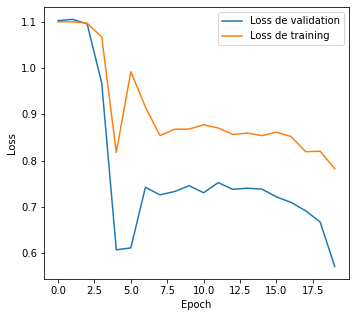

In [22]:
# Mettre ici le code nécessaire pour que je puisse évaluer votre modèle (après entrainement) sur un dataset de test dans un fichier test.npy
# 6. Visualisation et Evaluation du modèle 


def visualize_validation(val_losses, train_losses):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(val_losses, label='Loss de validation')
    plt.plot(train_losses, label='Loss de training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
visualize_validation(val_losses, train_losses)
    
# 7. Evaluation sur le test set
def evaluate_on_test(model, test_loader, criterion):
    model.eval()
    epoch_test_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    test_losses, test_accs = [], []

    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            y_batch = y_batch.squeeze()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            epoch_test_loss += loss.item()
            
            
            _, predicted = torch.max(y_pred.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            
            all_predictions.extend(predicted.numpy())
            all_labels.extend(y_batch.numpy())
    
    accuracy = 100 * correct / total
    avg_loss = epoch_test_loss / len(test_loader)
    
    print(f"results sur le test set ")
    print(f"Test loss: {avg_loss:.4f}")
    print(f"Test accuracy: {accuracy:.2f}%")
    print(f"Correct: {correct}/{total}")

    
    
    return accuracy, avg_loss, all_predictions, all_labels


#8.  #TODO  Fonction pour tester sur un fichier test (demandé par la prof)

# Évaluer sur notre test set
test_acc, test_loss, predictions, true_labels = evaluate_on_test(model, test_loader, criterion)
